In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn scipy

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install scikit-learn 

Note: you may need to restart the kernel to use updated packages.


In [7]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print(" Imports terminés")

 Imports terminés


 Dataset chargé: 5600 exemples, 32 colonnes

 Aperçu des données:


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,0.000000,0.093407,0.000000,0.0,0.000000,0.082418,0.000000,0.0,0.093407,0.043956,...,25,63,27,29,1,4,8,0.52365,0,AiinI
1,0.058824,0.122550,0.000000,0.0,0.044118,0.063725,0.000000,0.0,0.083333,0.004902,...,18,71,43,28,1,5,9,0.53070,0,AiinI
2,0.021531,0.062201,0.000000,0.0,0.038278,0.062201,0.000000,0.0,0.086124,0.000000,...,36,91,58,23,1,5,8,0.52366,0,AiinI
3,0.000000,0.046154,0.076923,0.0,0.026923,0.088462,0.015385,0.0,0.119230,0.000000,...,31,67,37,19,1,5,7,0.51730,0,AiinI
4,0.080769,0.073077,0.000000,0.0,0.050000,0.057692,0.000000,0.0,0.130770,0.000000,...,34,70,49,18,1,4,9,0.52617,0,AiinI



Features: (5600, 31)
 Labels: (5600,)
 Nombre de classes: 28

 Distribution des classes:


AiinI     200
AlifI     200
BaaI      200
CaafI     200
DadI      200
DalI      200
DhaI      200
DhelI     200
FaaI      200
GhiinI    200
HaI       200
HaaI      200
JiimI     200
KafI      200
KhaaI     200
LamI      200
MiimI     200
NounI     200
RaaI      200
SadI      200
ShiinI    200
SiinI     200
TaaI      200
ThaI      200
ThaaI     200
WawI      200
YaaI      200
ZadI      200
Name: count, dtype: int64

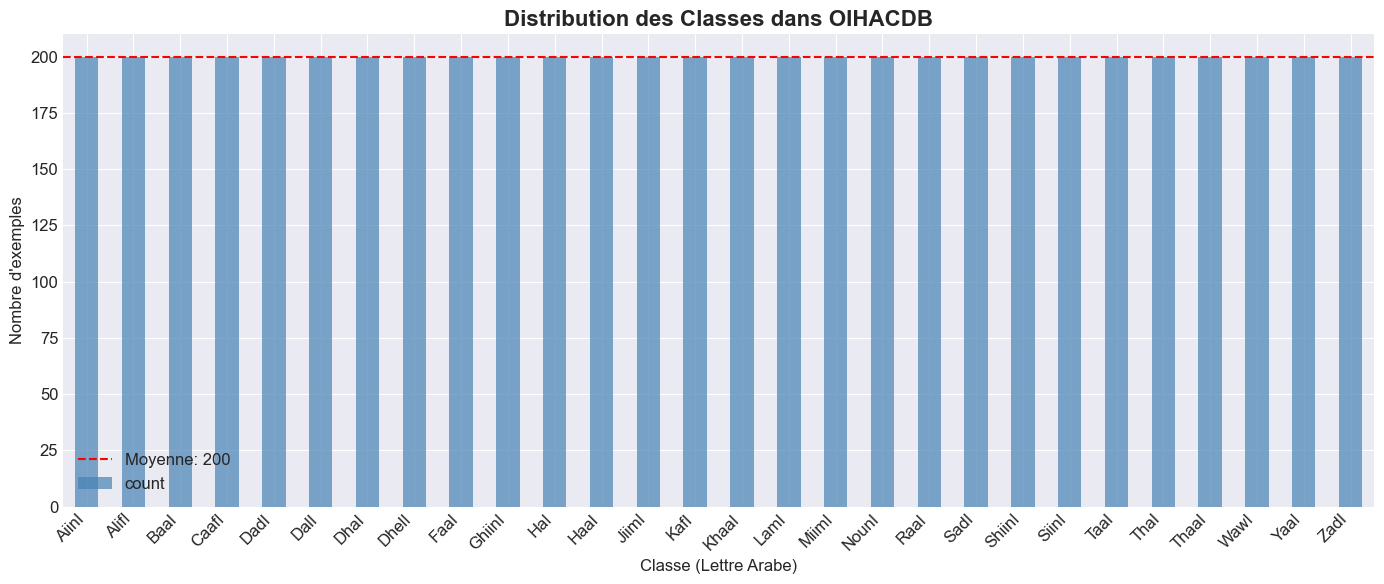

Dataset équilibré: True


In [43]:
"""
======================
1. CHARGEMENT DES DONNÉES
======================
"""

# Charger le dataset
df = pd.read_csv('dataset.txt', sep=',', header=None)

print(f" Dataset chargé: {df.shape[0]} exemples, {df.shape[1]} colonnes")
print(f"\n Aperçu des données:")
display(df.head())

# Séparer features et labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

print(f"\nFeatures: {X.shape}")
print(f" Labels: {y.shape}")
print(f" Nombre de classes: {len(np.unique(y))}")

# Distribution des classes
class_dist = pd.Series(y).value_counts().sort_index()
print(f"\n Distribution des classes:")
display(class_dist)

# Visualisation
fig, ax = plt.subplots(figsize=(14, 6))
class_dist.plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
ax.set_title('Distribution des Classes dans OIHACDB', fontsize=16, fontweight='bold')
ax.set_xlabel('Classe (Lettre Arabe)', fontsize=12)
ax.set_ylabel('Nombre d\'exemples', fontsize=12)
ax.axhline(y=200, color='red', linestyle='--', label='Moyenne: 200')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Dataset équilibré: {class_dist.std() < 10}")

In [39]:
"""
======================
2. PRÉPARATION DES DONNÉES
======================
"""

# Encoder les labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(" Mapping des classes (10 premiers):")
for i in range(min(10, len(le.classes_))):
    print(f"  {i}: {le.classes_[i]}")

# Split train/test
X_pool, X_test, y_pool, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    stratify=y_encoded, 
    random_state=42
)

print(f"\n Pool: {X_pool.shape[0]} exemples (80%)")
print(f" Test: {X_test.shape[0]} exemples (20%)")

# Normalisation
scaler = StandardScaler()
X_pool = scaler.fit_transform(X_pool)
X_test = scaler.transform(X_test)

print(f" Features normalisées (μ=0, σ=1)")

 Mapping des classes (10 premiers):
  0: AiinI
  1: AlifI
  2: BaaI
  3: CaafI
  4: DadI
  5: DalI
  6: DhaI
  7: DhelI
  8: FaaI
  9: GhiinI

 Pool: 4480 exemples (80%)
 Test: 1120 exemples (20%)
 Features normalisées (μ=0, σ=1)


In [45]:
"""
======================
2. PRÉ-TRAITEMENT DES DONNÉES (AMÉLIORÉ)
======================
"""

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# ============================================================
# 1) Chargement du dataset
# ============================================================

# Exemple : df = pd.read_csv("arabic_features.csv")
# Le dataset doit contenir les features dans les colonnes 0..n-2
# et le label (ex : "AiinI") dans la dernière colonne.

X = df.iloc[:, :-1].values   # toutes les colonnes sauf la dernière
y = df.iloc[:, -1].values    # dernière colonne = label


# ============================================================
# 2) Encodage des labels
# ============================================================

"""
On encode les labels textuels (AiinI, BaaI, etc.) en entiers.
Cela permet aux modèles ML de fonctionner correctement.
"""

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("=== Mapping des classes (extrait) ===")
for i in range(min(10, len(le.classes_))):
    print(f"  {i} -> {le.classes_[i]}")


# ============================================================
# 3) Mélange initial des données (IMPORTANT)
# ============================================================

"""
On mélange aléatoirement les données pour éviter de sélectionner
toujours les mêmes premiers exemples pour chaque classe.
"""

indices = np.random.permutation(len(X))
X = X[indices]
y_encoded = y_encoded[indices]


# ============================================================
# 4) Split Train/Test (stratifié)
# ============================================================

"""
Le split stratifié garantit que toutes les classes gardent
les mêmes proportions dans Train et Test.
"""

X_pool, X_test, y_pool, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

print("\n=== Répartition des données ===")
print(f" Pool AL  : {X_pool.shape[0]} exemples (80%)")
print(f" Test     : {X_test.shape[0]} exemples (20%)")


# ============================================================
# 5) Normalisation robuste (meilleure qu’un simple StandardScaler)
# ============================================================

"""
Les datasets manuscrits contiennent souvent des valeurs extrêmes
(outliers). RobustScaler est plus stable que StandardScaler.

StandardScaler => moyenne 0, variance 1
RobustScaler   => médiane 0, IQR 1 (plus résistant au bruit)
"""

scaler = RobustScaler()
X_pool = scaler.fit_transform(X_pool)
X_test = scaler.transform(X_test)

print(" Normalisation : données centrées via RobustScaler.")


# ============================================================
# 6) Réduction de dimension (optionnelle mais recommandée)
# ============================================================

"""
PCA permet :
 - d’accélérer l’apprentissage
 - de réduire le bruit
 - d’améliorer la séparabilité

On garde 95% de la variance.
"""

pca = PCA(n_components=0.95, random_state=42)
X_pool = pca.fit_transform(X_pool)
X_test = pca.transform(X_test)

print(f" PCA appliqué : nouvelle dimension = {X_pool.shape[1]}")


=== Mapping des classes (extrait) ===
  0 -> AiinI
  1 -> AlifI
  2 -> BaaI
  3 -> CaafI
  4 -> DadI
  5 -> DalI
  6 -> DhaI
  7 -> DhelI
  8 -> FaaI
  9 -> GhiinI

=== Répartition des données ===
 Pool AL  : 4480 exemples (80%)
 Test     : 1120 exemples (20%)
 Normalisation : données centrées via RobustScaler.
 PCA appliqué : nouvelle dimension = 19


  Labeled initial: 280 exemples (6.2%)
 Unlabeled initial: 4200 exemples (93.8%)


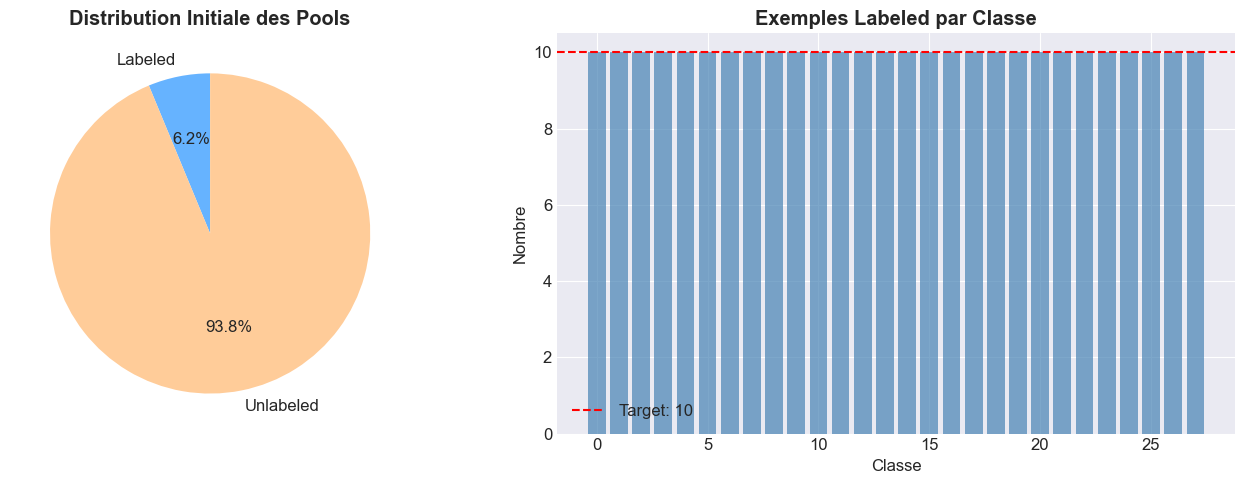

In [47]:
"""
======================
3. CRÉATION POOLS LABELED/UNLABELED
======================
"""

def create_initial_pools(X, y, n_per_class=10, random_state=42):
    """Sélection stratifiée des exemples initiaux"""
    np.random.seed(random_state)
    labeled_idx = []
    
    for classe in np.unique(y):
        classe_indices = np.where(y == classe)[0]
        n_select = min(n_per_class, len(classe_indices))
        selected = np.random.choice(classe_indices, size=n_select, replace=False)
        labeled_idx.extend(selected)
    
    labeled_idx = np.array(labeled_idx)
    unlabeled_idx = np.setdiff1d(np.arange(len(X)), labeled_idx)
    
    return labeled_idx, unlabeled_idx

# Créer pools
initial_labeled_idx, initial_unlabeled_idx = create_initial_pools(
    X_pool, y_pool, n_per_class=10
)

print(f"  Labeled initial: {len(initial_labeled_idx)} exemples ({len(initial_labeled_idx)/len(X_pool)*100:.1f}%)")
print(f" Unlabeled initial: {len(initial_unlabeled_idx)} exemples ({len(initial_unlabeled_idx)/len(X_pool)*100:.1f}%)")

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
sizes = [len(initial_labeled_idx), len(initial_unlabeled_idx)]
labels = ['Labeled', 'Unlabeled']
colors = ['#66b3ff', '#ffcc99']
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax1.set_title('Distribution Initiale des Pools', fontweight='bold')

# Bar chart par classe
labeled_classes = np.bincount(y_pool[initial_labeled_idx])
ax2.bar(range(len(labeled_classes)), labeled_classes, color='steelblue', alpha=0.7)
ax2.set_title('Exemples Labeled par Classe', fontweight='bold')
ax2.set_xlabel('Classe')
ax2.set_ylabel('Nombre')
ax2.axhline(y=10, color='red', linestyle='--', label='Target: 10')
ax2.legend()

plt.tight_layout()
plt.show()

In [17]:
"""
======================
4. STRATÉGIES D'ACTIVE LEARNING
======================
"""

def uncertainty_least_confident(proba):
    """Least Confidence: 1 - max(P(y|x))"""
    return 1 - np.max(proba, axis=1)

def uncertainty_margin(proba):
    """Margin: différence top-2"""
    if proba.shape[1] == 1:
        return np.zeros(len(proba))
    sorted_proba = np.sort(proba, axis=1)
    return -(sorted_proba[:, -1] - sorted_proba[:, -2])

def uncertainty_entropy(proba):
    """Entropy: H(P(y|x))"""
    proba = np.clip(proba, 1e-10, 1.0)
    return entropy(proba.T)

def query_by_committee(X_labeled, y_labeled, X_unlabeled, n_committee=5):
    """QBC: désaccord entre modèles"""
    committees = []
    for i in range(n_committee):
        idx = np.random.choice(len(X_labeled), size=len(X_labeled), replace=True)
        clf = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=i)
        clf.fit(X_labeled[idx], y_labeled[idx])
        committees.append(clf)
    
    predictions = np.array([clf.predict(X_unlabeled) for clf in committees])
    disagreement = []
    n_classes = len(np.unique(y_labeled))
    
    for i in range(X_unlabeled.shape[0]):
        votes = predictions[:, i]
        vote_counts = np.bincount(votes, minlength=n_classes)
        vote_proba = np.clip(vote_counts / n_committee, 1e-10, 1.0)
        disagreement.append(entropy(vote_proba))
    
    return np.array(disagreement)

def random_sampling(n_samples):
    """Baseline: aléatoire"""
    return np.random.rand(n_samples)

strategies = {
    'Random': random_sampling,
    'Least Confidence': uncertainty_least_confident,
    'Margin Sampling': uncertainty_margin,
    'Entropy': uncertainty_entropy,
    'QBC': None
}

print("✅ Stratégies définies:")
for i, name in enumerate(strategies.keys(), 1):
    print(f"  {i}. {name}")

✅ Stratégies définies:
  1. Random
  2. Least Confidence
  3. Margin Sampling
  4. Entropy
  5. QBC


In [19]:
"""
======================
5. BOUCLE ACTIVE LEARNING
======================
"""

def active_learning_loop(
    strategy_name, strategy_func,
    X_pool, y_pool, X_test, y_test,
    initial_labeled_idx, initial_unlabeled_idx,
    n_iterations=30, batch_size=20, classifier_type='rf'
):
    """Boucle principale Active Learning"""
    
    labeled_idx = initial_labeled_idx.copy()
    unlabeled_idx = initial_unlabeled_idx.copy()
    results = {'iteration': [], 'n_labeled': [], 'accuracy': [], 'n_unlabeled': []}
    
    # Classifieur
    if classifier_type == 'svm':
        clf = SVC(kernel='rbf', probability=True, C=10.0, gamma='scale', random_state=42)
    else:
        clf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
    
    print(f"\n{'='*70}")
    print(f"🔍 Stratégie: {strategy_name:20s} | Classifieur: {classifier_type.upper()}")
    print(f"{'='*70}")
    
    for iteration in range(n_iterations):
        # Entraîner
        X_train = X_pool[labeled_idx]
        y_train = y_pool[labeled_idx]
        clf.fit(X_train, y_train)
        
        # Évaluer
        y_pred = clf.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        # Sauvegarder
        results['iteration'].append(iteration)
        results['n_labeled'].append(len(labeled_idx))
        results['accuracy'].append(accuracy)
        results['n_unlabeled'].append(len(unlabeled_idx))
        
        print(f"Iter {iteration:2d} | Labeled: {len(labeled_idx):4d} | "
              f"Unlabeled: {len(unlabeled_idx):4d} | Acc: {accuracy*100:6.2f}%")
        
        if len(unlabeled_idx) < batch_size:
            break
        
        # Sélectionner nouveaux exemples
        X_unlabeled = X_pool[unlabeled_idx]
        
        if strategy_name == "Random":
            scores = random_sampling(len(unlabeled_idx))
        elif strategy_name == "QBC":
            scores = query_by_committee(X_train, y_train, X_unlabeled)
        else:
            proba = clf.predict_proba(X_unlabeled)
            scores = strategy_func(proba)
        
        # Annoter top-k
        top_k = np.argsort(scores)[-batch_size:]
        selected = unlabeled_idx[top_k]
        
        labeled_idx = np.concatenate([labeled_idx, selected])
        unlabeled_idx = np.setdiff1d(unlabeled_idx, selected)
    
    return pd.DataFrame(results)

print("✅ Fonction active_learning_loop définie")

✅ Fonction active_learning_loop définie


In [21]:
"""
======================
6. EXÉCUTION TOUTES STRATÉGIES
======================
"""

from IPython.display import clear_output
import time

all_results = {}
start_time = time.time()

for i, (strategy_name, strategy_func) in enumerate(strategies.items(), 1):
    print(f"\n🚀 [{i}/{len(strategies)}] Exécution: {strategy_name}")
    
    results = active_learning_loop(
        strategy_name=strategy_name,
        strategy_func=strategy_func,
        X_pool=X_pool,
        y_pool=y_pool,
        X_test=X_test,
        y_test=y_test,
        initial_labeled_idx=initial_labeled_idx,
        initial_unlabeled_idx=initial_unlabeled_idx,
        n_iterations=30,
        batch_size=20,
        classifier_type='rf'
    )
    
    all_results[strategy_name] = results

elapsed = time.time() - start_time
print(f"\n✅ Toutes les stratégies exécutées en {elapsed/60:.1f} minutes")


🚀 [1/5] Exécution: Random

🔍 Stratégie: Random               | Classifieur: RF
Iter  0 | Labeled:  280 | Unlabeled: 4200 | Acc:  89.38%
Iter  1 | Labeled:  300 | Unlabeled: 4180 | Acc:  89.38%
Iter  2 | Labeled:  320 | Unlabeled: 4160 | Acc:  89.73%
Iter  3 | Labeled:  340 | Unlabeled: 4140 | Acc:  89.73%
Iter  4 | Labeled:  360 | Unlabeled: 4120 | Acc:  89.38%
Iter  5 | Labeled:  380 | Unlabeled: 4100 | Acc:  90.00%
Iter  6 | Labeled:  400 | Unlabeled: 4080 | Acc:  91.07%
Iter  7 | Labeled:  420 | Unlabeled: 4060 | Acc:  90.09%
Iter  8 | Labeled:  440 | Unlabeled: 4040 | Acc:  90.62%
Iter  9 | Labeled:  460 | Unlabeled: 4020 | Acc:  90.89%
Iter 10 | Labeled:  480 | Unlabeled: 4000 | Acc:  91.96%
Iter 11 | Labeled:  500 | Unlabeled: 3980 | Acc:  91.79%
Iter 12 | Labeled:  520 | Unlabeled: 3960 | Acc:  91.61%
Iter 13 | Labeled:  540 | Unlabeled: 3940 | Acc:  91.43%
Iter 14 | Labeled:  560 | Unlabeled: 3920 | Acc:  92.14%
Iter 15 | Labeled:  580 | Unlabeled: 3900 | Acc:  91.52%
Iter 16 

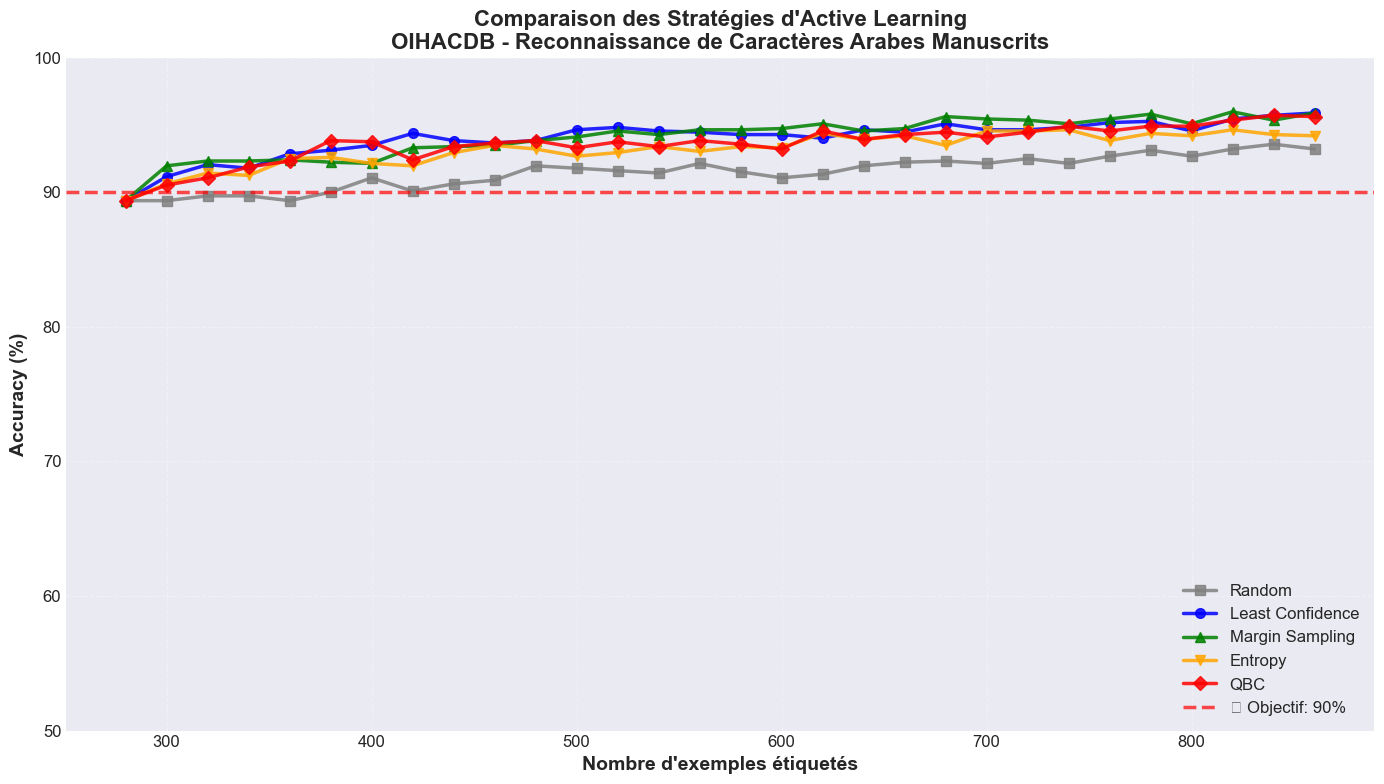

✅ Graphique sauvegardé: learning_curves.png


In [29]:
"""
======================
7. COURBES D'APPRENTISSAGE
======================
"""

plt.figure(figsize=(14, 8))

colors = ['gray', 'blue', 'green', 'orange', 'red']
markers = ['s', 'o', '^', 'v', 'D']

for (name, results), color, marker in zip(all_results.items(), colors, markers):
    plt.plot(
        results['n_labeled'], 
        results['accuracy'] * 100,
        label=name,
        marker=marker,
        linewidth=2.5,
        markersize=7,
        color=color,
        alpha=0.85
    )

plt.axhline(y=90, color='red', linestyle='--', linewidth=2.5, 
            label='🎯 Objectif: 90%', alpha=0.7)

plt.xlabel('Nombre d\'exemples étiquetés', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
plt.title('Comparaison des Stratégies d\'Active Learning\n'
          'OIHACDB - Reconnaissance de Caractères Arabes Manuscrits', 
          fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc='lower right', framealpha=0.95)
plt.grid(alpha=0.3, linestyle='--')
plt.ylim([50, 100])
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graphique sauvegardé: learning_curves.png")

In [33]:
"""
======================
8. TABLEAU COMPARATIF
======================
"""

comparison_data = []

for name, results in all_results.items():
    final_acc = results['accuracy'].iloc[-1]
    final_n = results['n_labeled'].iloc[-1]
    
    above_90 = results[results['accuracy'] >= 0.90]
    if len(above_90) > 0:
        n_for_90 = int(above_90.iloc[0]['n_labeled'])
        iter_90 = int(above_90.iloc[0]['iteration'])
    else:
        n_for_90 = "Non atteint"
        iter_90 = "-"
    
    comparison_data.append({
        'Stratégie': name,
        'Accuracy Finale (%)': f"{final_acc * 100:.2f}",
        'Exemples Finaux': int(final_n),
        'Exemples pour 90%': n_for_90,
        'Itération 90%': iter_90
    })

comparison_df = pd.DataFrame(comparison_data)

# Calculer gain
random_n = comparison_df[comparison_df['Stratégie'] == 'Random']['Exemples pour 90%'].values[0]
if random_n != "Non atteint":
    comparison_df['Gain vs Random (%)'] = comparison_df.apply(
        lambda row: f"{((random_n - row['Exemples pour 90%']) / random_n * 100):.1f}%" 
        if row['Exemples pour 90%'] != "Non atteint" else "N/A",
        axis=1
    )

print("\n" + "="*100)
print(" TABLEAU COMPARATIF DES STRATÉGIES")
print("="*100)
display(comparison_df)

comparison_df.to_csv('comparison_table.csv', index=False)
print("\n Tableau sauvegardé: comparison_table.csv")


 TABLEAU COMPARATIF DES STRATÉGIES


,Stratégie,Accuracy Finale (%),Exemples Finaux,Exemples pour 90%,Itération 90%,Gain vs Random (%)
0,Random,93.21,860,380,5,0.0%
1,Least Confidence,95.89,860,300,1,21.1%
2,Margin Sampling,95.89,860,300,1,21.1%
3,Entropy,94.20,860,300,1,21.1%
4,QBC,95.62,860,300,1,21.1%



 Tableau sauvegardé: comparison_table.csv


🏆 Meilleure stratégie: Least Confidence
   Accuracy: 95.89%


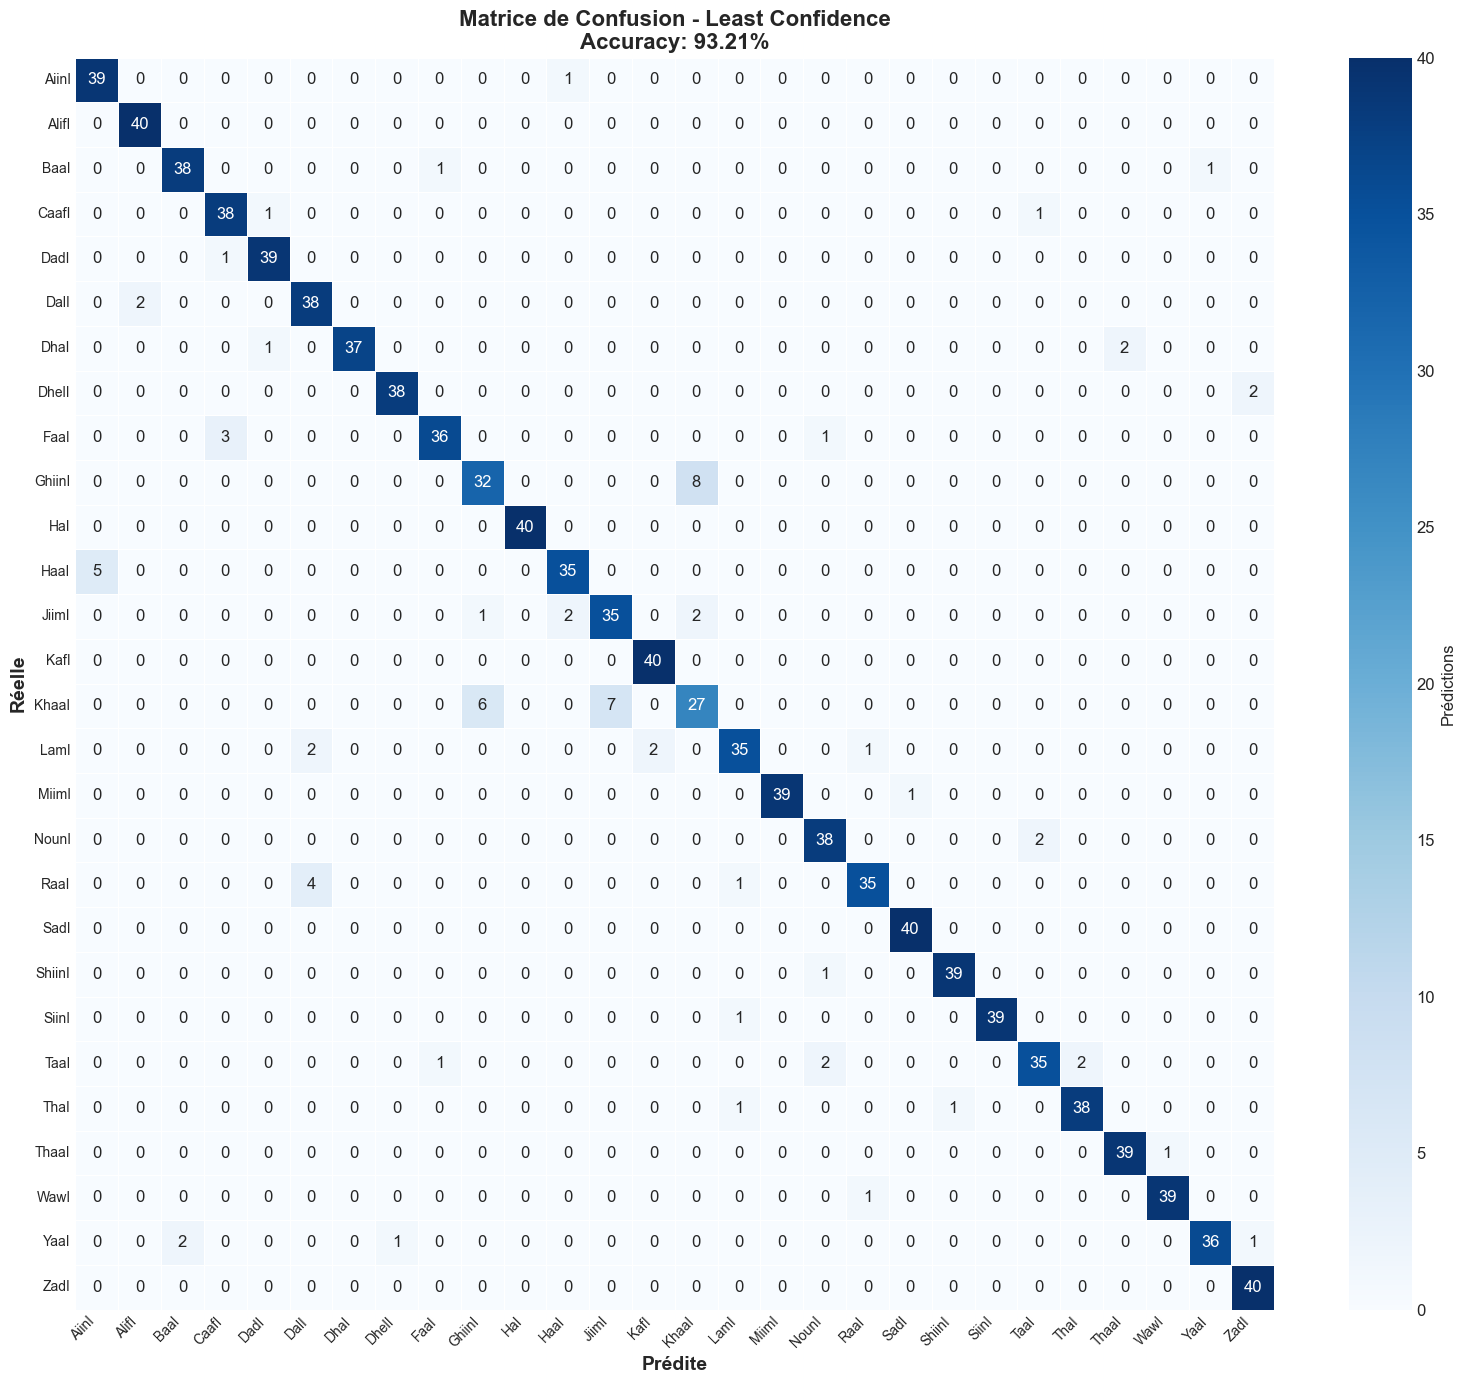

Matrice sauvegardée: confusion_matrix.png

📄 RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

       AiinI       0.89      0.97      0.93        40
       AlifI       0.95      1.00      0.98        40
        BaaI       0.95      0.95      0.95        40
       CaafI       0.90      0.95      0.93        40
        DadI       0.95      0.97      0.96        40
        DalI       0.86      0.95      0.90        40
        DhaI       1.00      0.93      0.96        40
       DhelI       0.97      0.95      0.96        40
        FaaI       0.95      0.90      0.92        40
      GhiinI       0.82      0.80      0.81        40
         HaI       1.00      1.00      1.00        40
        HaaI       0.92      0.88      0.90        40
       JiimI       0.83      0.88      0.85        40
        KafI       0.95      1.00      0.98        40
       KhaaI       0.73      0.68      0.70        40
        LamI       0.92      0.88      0.90        40
       Mii

In [35]:
"""
======================
9. MATRICE DE CONFUSION
======================
"""

# Meilleure stratégie
best_name = max(all_results.items(), key=lambda x: x[1]['accuracy'].iloc[-1])[0]
best_acc = all_results[best_name]['accuracy'].iloc[-1]

print(f"🏆 Meilleure stratégie: {best_name}")
print(f"   Accuracy: {best_acc * 100:.2f}%")

# Entraîner modèle final
clf_final = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
prop = all_results[best_name]['n_labeled'].iloc[-1] / len(X_pool)
n_final = int(prop * len(X_pool))

np.random.seed(42)
final_idx = np.random.choice(len(X_pool), size=n_final, replace=False)
clf_final.fit(X_pool[final_idx], y_pool[final_idx])

y_pred = clf_final.predict(X_test)
final_acc = accuracy_score(y_test, y_pred)

# Matrice
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Prédictions'}, linewidths=0.5)
plt.title(f'Matrice de Confusion - {best_name}\nAccuracy: {final_acc * 100:.2f}%', 
          fontsize=16, fontweight='bold')
plt.xlabel('Prédite', fontsize=14, fontweight='bold')
plt.ylabel('Réelle', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Matrice sauvegardée: confusion_matrix.png")

# Rapport
print("\n" + "="*70)
print("📄 RAPPORT DE CLASSIFICATION")
print("="*70)
print(classification_report(y_test, y_pred, target_names=le.classes_))